# Benchmark of ML models

### Decision tree regressor

In [1]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from pandas import read_csv
from pickle import load

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [48]:
# Read the best fit hyperparameters
file = open('../src/data_mining/trained_models/rf_model_tuned_v1.pkl', 'rb')
best_fit_model = load(file)
file.close()

ModuleNotFoundError: No module named 'pycaret'

In [9]:
df = read_csv('../data/final_datasets/transformed_datasets/transformed_training_data.csv')
for col, corr in zip(df.columns, df.corr(method='spearman')['UHI Index']):
    print(col, corr)

gndvi_median_res10 -0.23242072169639502
datt1_median_res10 -0.10108123020924105
fs_median_res10 0.23669203740624217
siwsi_median_res10 -0.23756384399757405
ndmi_median_res10 -0.19692658420060125
si_median_res10 0.14768125141276878
w_median_res10 -0.13322188268910745
evi_median_res10 -0.20325645482723342
B2_median_res10 0.17331527364580235
B3_median_res10 0.1707866849907093
B4_median_res10 0.1721538369503773
B5_median_res10 0.16861792634929842
B7_median_res10 -0.10985123255260303
B8_median_res10 -0.1322424711376458
B8A_median_res10 -0.12267888198808166
B11_median_res10 0.10195918314314867
B12_median_res10 0.18389258468059266
gndvi_median_res100 -0.26960740029197466
fs_median_res100 0.2837008754309153
siwsi_median_res100 -0.24280627620865802
ndmi_median_res100 -0.2106285087572004
si_median_res100 0.20226765685218298
w_median_res100 -0.21816191047909567
evi_median_res100 -0.17787421787852986
B2_median_res100 0.3533079227784651
B3_median_res100 0.3587435015314258
B4_median_res100 0.3560548

In [ ]:
# Taken from https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html#sphx-glr-auto-examples-tree-plot-cost-complexity-pruning-py

df = read_csv('../data/final_datasets/transformed_datasets/transformed_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

rgr = DecisionTreeRegressor(random_state = 0)
path = rgr.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

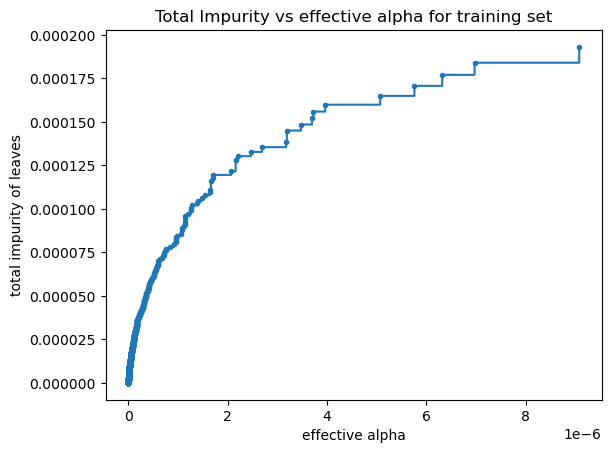

In [11]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", markersize = 3.0, drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

In [13]:
rgrs = []
for ccp_alpha in ccp_alphas[1:]:
    rgr = DecisionTreeRegressor(random_state = 0, 
                                ccp_alpha = ccp_alpha, 
                                criterion = 'squared_error', 
                                max_features = 0.8, 
                                min_samples_split = 0.00017239623972536324,
                                min_samples_leaf = 0.0006733944396699074,
                                splitter = 'best')
    rgr.fit(X_train, y_train)
    rgrs.append(rgr)
    
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(rgrs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 6.963031797574323e-05


In [14]:
total_sum = 0.0

for rgr in rgrs:
    total_sum += rgr.feature_importances_
    
# Compute the mean of the feature importances
total_sum = total_sum/len(total_sum)

In [15]:
corr = df.corr(method = 'spearman')

In [16]:
for column, correlation, importance in zip(df.columns[:-1], corr['UHI Index'].values[:-1], total_sum):
    print(column, correlation, importance)

gndvi_median_res10 -0.23242072169639502 0.06028499657599758
datt1_median_res10 -0.10108123020924105 0.025012587213504512
fs_median_res10 0.23669203740624217 0.06710313467590177
siwsi_median_res10 -0.23756384399757405 0.044361243397541106
ndmi_median_res10 -0.19692658420060125 0.035254517392459175
si_median_res10 0.14768125141276878 0.03223474580488519
w_median_res10 -0.13322188268910745 0.033547494551637615
evi_median_res10 -0.20325645482723342 0.0446409363933927
B2_median_res10 0.17331527364580235 0.008739899205653516
B3_median_res10 0.1707866849907093 0.07969694950251549
B4_median_res10 0.1721538369503773 0.014882371706610477
B5_median_res10 0.16861792634929842 0.024118816199162924
B7_median_res10 -0.10985123255260303 0.021234298398453335
B8_median_res10 -0.1322424711376458 0.03702737128134096
B8A_median_res10 -0.12267888198808166 0.0168880777076422
B11_median_res10 0.10195918314314867 0.12448434010292138
B12_median_res10 0.18389258468059266 0.01819065519658822
gndvi_median_res100 -0

Los que más suman son: LST, Polygon density y Air temperature at surface

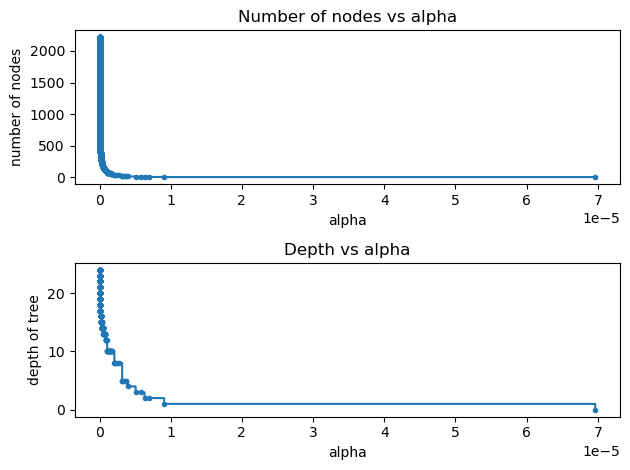

In [18]:
node_counts = [rgr.tree_.node_count for rgr in rgrs]
depth = [rgr.tree_.max_depth for rgr in rgrs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas[1:], node_counts, marker = "o", markersize = 3.0, drawstyle = "steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")

ax[1].plot(ccp_alphas[1:], depth, marker = "o", markersize = 3.0, drawstyle = "steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

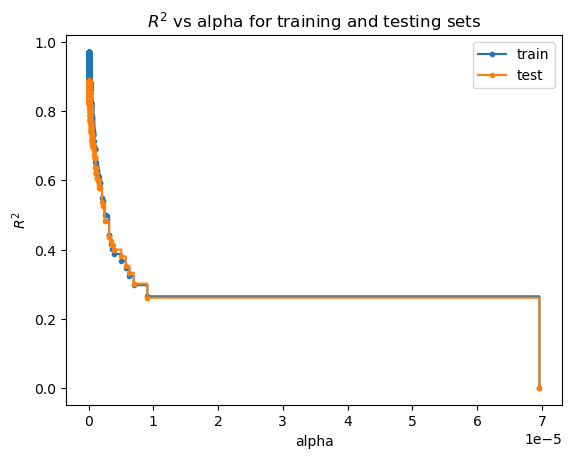

In [19]:
train_predictions = [rgr.predict(X_train) for rgr in rgrs]
test_predictions = [rgr.predict(X_test) for rgr in rgrs]

r2_train = [r2_score(y_train, y_pred) for y_pred in train_predictions]
r2_test = [r2_score(y_test, y_pred) for y_pred in test_predictions]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs alpha for training and testing sets")
ax.plot(ccp_alphas[1:], r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(ccp_alphas[1:], r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

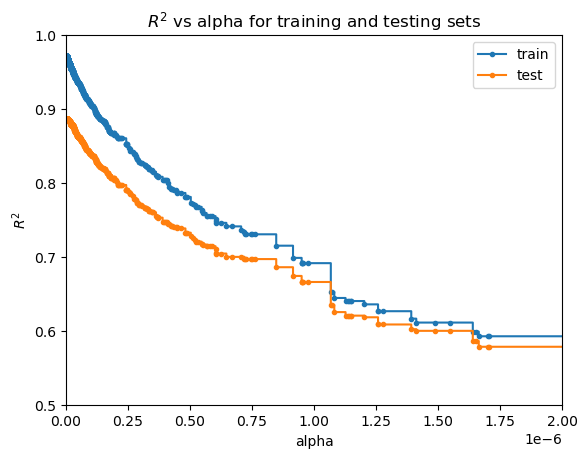

In [20]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs alpha for training and testing sets")
ax.plot(ccp_alphas[1:], r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(ccp_alphas[1:], r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.set_xlim(0.0, 0.2e-5)
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.show()

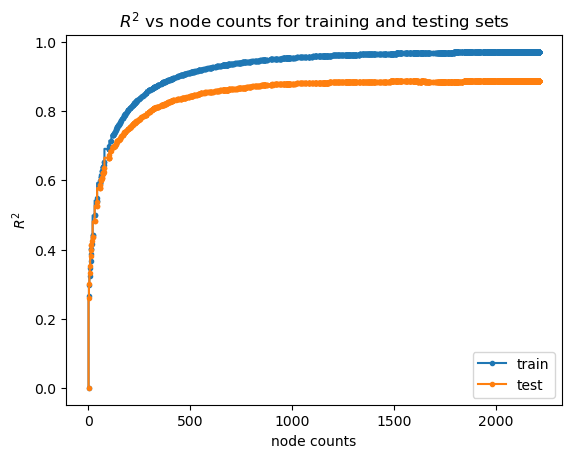

In [21]:
fig, ax = plt.subplots()
ax.set_xlabel("node counts")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs node counts for training and testing sets")
ax.plot(node_counts, r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(node_counts, r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

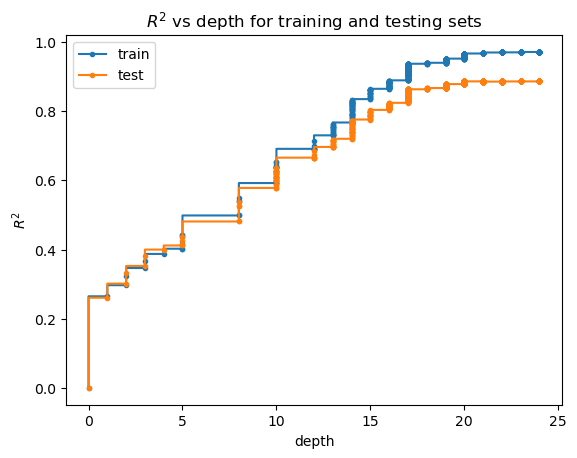

In [22]:
fig, ax = plt.subplots()
ax.set_xlabel("depth")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs depth for training and testing sets")
ax.plot(depth, r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(depth, r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

### Random forest regressor

In [40]:
# Packages
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import make_scorer
r2 = make_scorer(r2_score)
from sklearn.inspection import permutation_importance
from pandas import read_csv, Series
from numpy import std

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [ ]:
# Dataset
df = read_csv('../data/final_datasets/transformed_datasets/transformed_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, stratify=y)

# Model
rfr = RandomForestRegressor(n_estimators = 1000, 
                            criterion = 'squared_error',
                            ccp_alpha = 5.93279137e-20, 
                            max_features = 0.8, 
                            max_leaf_nodes = 1900,
                            min_samples_split = 0.00017239623972536324,
                            min_samples_leaf = 0.0006733944396699074, 
                            max_depth = 20,
                            random_state = 10)

In [42]:
# Fit the model
rfr.fit(X_train, y_train)

RandomForestRegressor(ccp_alpha=5.93279137e-20, max_depth=20, max_features=0.8,
                      max_leaf_nodes=1900,
                      min_samples_leaf=0.0006733944396699074,
                      min_samples_split=0.00017239623972536324,
                      n_estimators=1000, random_state=10)

In [43]:
# Compute importances
importances = rfr.feature_importances_

# Compute standard deviation for each feature importance
importances_std = std([tree.feature_importances_ for tree in rfr.estimators_], axis = 0)

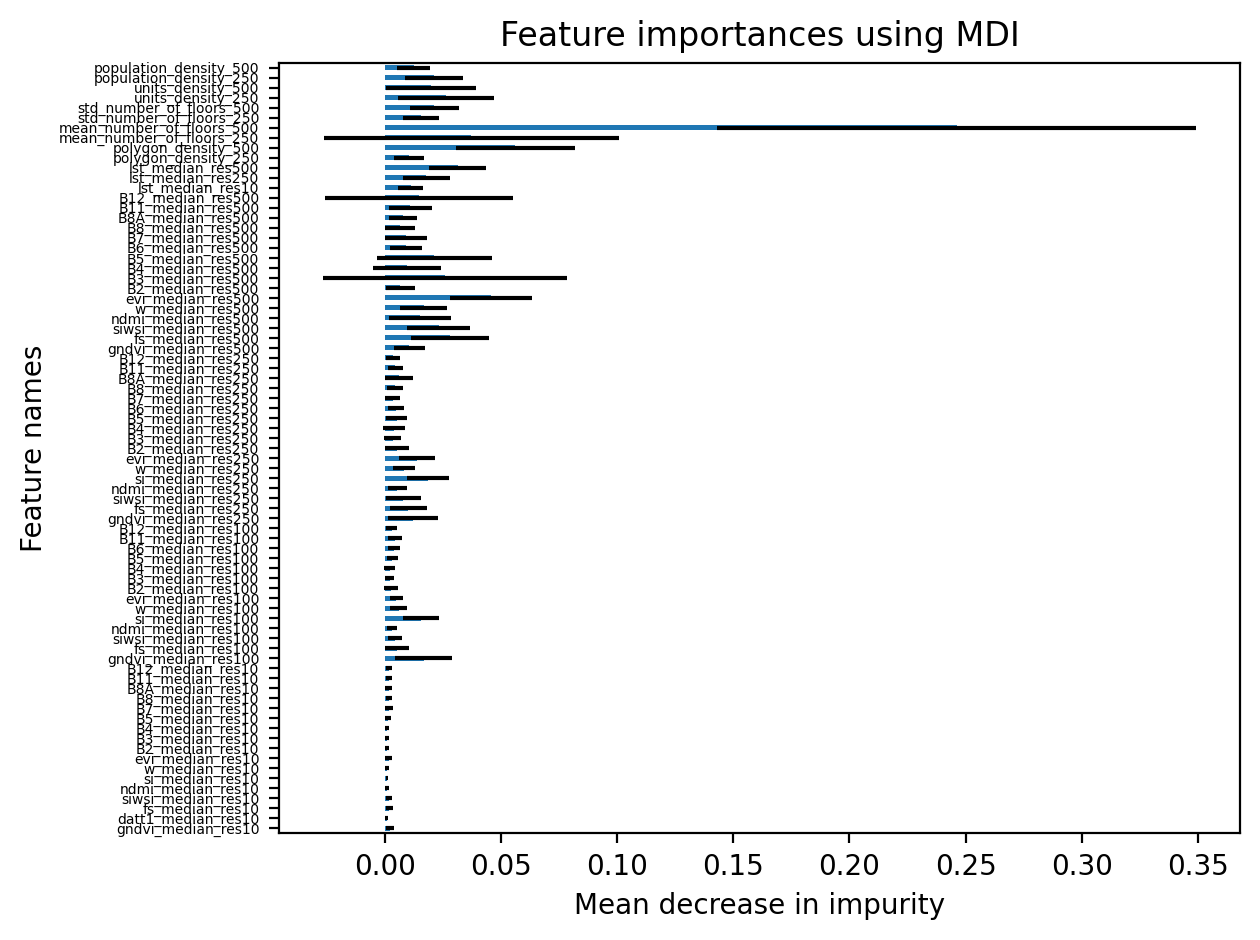

In [44]:
# Impurity-based importance plot
forest_importances = Series(importances, index = X_train.columns)

fig, ax = plt.subplots(1, 1, dpi = 200)
forest_importances.plot.barh(xerr = importances_std, ax = ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Feature names")
ax.set_xlabel("Mean decrease in impurity")
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 5)
fig.tight_layout()

In [45]:
print(r2_score(y_train, rfr.predict(X_train)))
print(r2_score(y_test, rfr.predict(X_test)))

0.9756014324795261
0.9377800473558702


In [46]:
# Compute permutation importance
result = permutation_importance(rfr, X_test, y_test, scoring = r2, n_repeats = 10, random_state = 42)

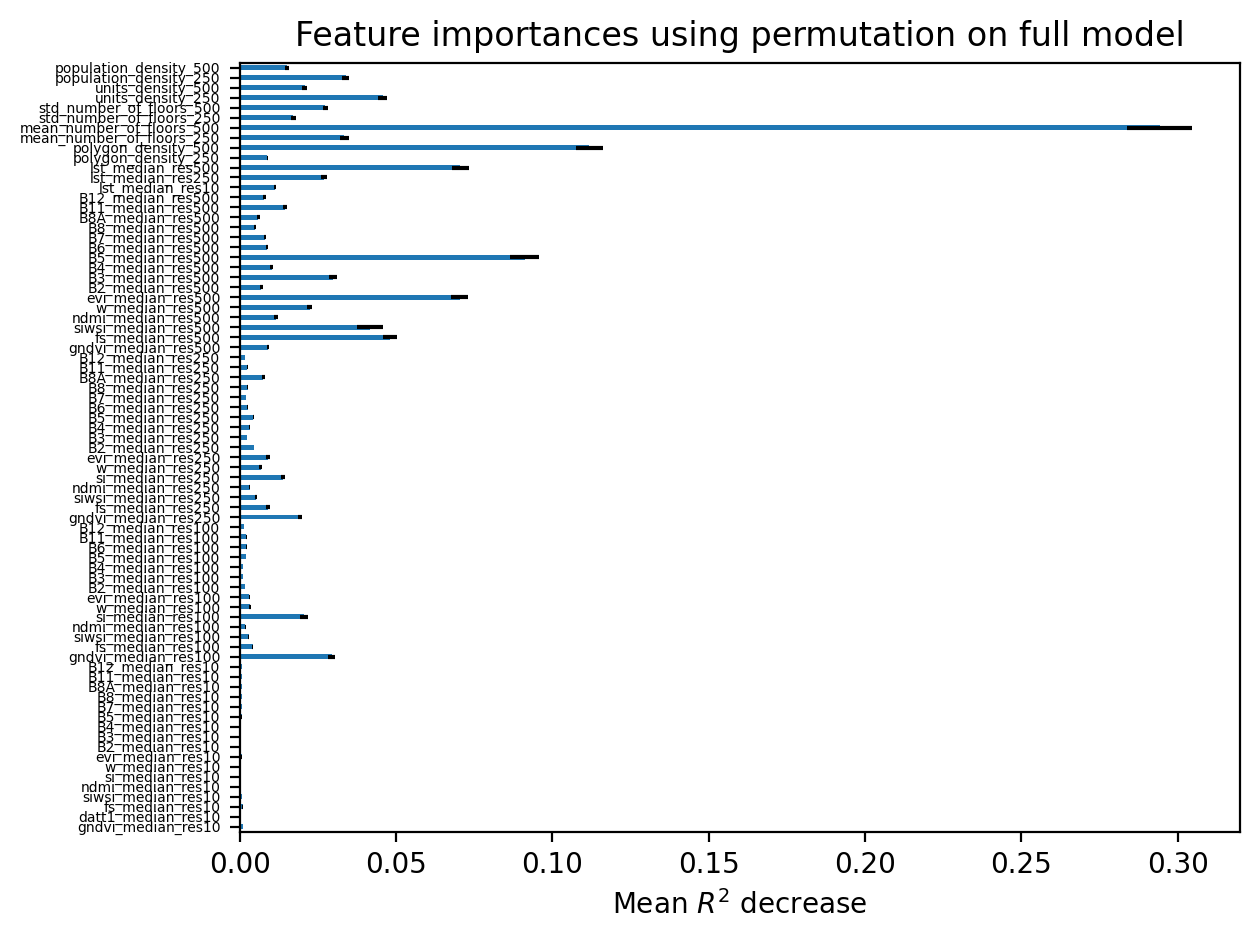

In [47]:
# Covert importances to Series object
forest_permutation_importances = Series(result.importances_mean, index = X_train.columns)

# Plot the importance ranking
fig, ax = plt.subplots(1, 1, dpi = 200)
forest_permutation_importances.plot.barh(xerr = result.importances_std, ax = ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_xlabel("Mean $R^{2}$ decrease")
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 5)
fig.tight_layout()
plt.show()

### XGBoost regressor

In [142]:
# Packages
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.metrics import r2_score
from pandas import read_csv
from numpy import logspace
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [ ]:
# Dataset
df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_oversampled_98imp_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

# XGBoost Regressor
xgbr = XGBRegressor(nthread = -1, 
                     colsample_bylevel = 0.27089875569868677,
                     colsample_bynode = 0.00023871262162442934,
                     colsample_bytree = 0.2521310852858073,
                     eta = 0.16984948183848828,
                     gamma = 4.936495008750438e-07, 
                     max_depth = 9, 
                     min_child_weight = 1.1130829945563475e-06, 
                     reg_alpha = 0.00027764020436691245, 
                     reg_lambda = 0.11543156340963502, 
                     subsample = 0.6725418424266979, 
                     tree_method = 'auto',
                     random_state = 10)

In [144]:
# Train the model
xgbr.fit(X_train.values, y_train.values)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.27089875569868677,
             colsample_bynode=0.00023871262162442934,
             colsample_bytree=0.2521310852858073, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=0.16984948183848828, eval_metric=None, feature_types=None,
             gamma=4.936495008750438e-07, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=1.1130829945563475e-06,
             missing=nan, monotone_constraints=None, multi_strategy=None,
             n_estimators=None, n_jobs=None, nthread=-1, ...)

In [145]:
# Predict
train_predictions = xgbr.predict(X_train.values)
test_predictions = xgbr.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 0.9795873415225761
R^2 over test data: 0.7749998324028481


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

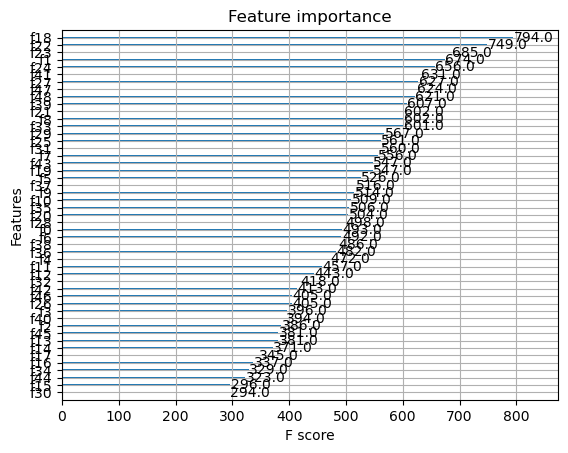

In [146]:
plot_importance(xgbr)

In [147]:
xgbr.feature_importances_*100.0

array([1.4435086 , 0.9532061 , 1.3707329 , 1.0273958 , 1.6720569 ,
       1.2897582 , 0.6113356 , 0.7615282 , 1.3077731 , 0.91191304,
       2.5118508 , 0.87915176, 0.58417845, 2.5267708 , 1.1146128 ,
       7.9926186 , 3.1948838 , 1.2218277 , 1.3174583 , 1.1997302 ,
       1.2407905 , 1.4972559 , 1.6662452 , 1.3503975 , 1.6643177 ,
       2.3335147 , 1.6899794 , 3.0868983 , 4.248441  , 0.7073043 ,
       1.7855774 , 1.3098493 , 2.4195786 , 2.7721808 , 4.918443  ,
       6.381337  , 1.0295849 , 0.9295331 , 2.0397246 , 1.8760182 ,
       1.2612253 , 1.6471572 , 1.5729573 , 1.9091865 , 1.8701961 ,
       4.365998  , 5.4315686 , 1.2657616 , 1.8366824 ], dtype=float32)

In [148]:
# Set array of eta values
eta = logspace(-7, 0, 100)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, eta_value in enumerate(eta):
    # Set a new model
    xgbr = XGBRegressor(nthread = -1, 
                        colsample_bylevel = 0.27089875569868677,
                        colsample_bynode = 0.00023871262162442934,
                        colsample_bytree = 0.2521310852858073,
                        eta = eta_value,
                        gamma = 4.936495008750438e-07, 
                        max_depth = 9, 
                        min_child_weight = 1.1130829945563475e-06, 
                        reg_alpha = 0.00027764020436691245, 
                        reg_lambda = 0.11543156340963502, 
                        subsample = 0.6725418424266979, 
                        tree_method = 'auto',
                        random_state = 10)
    
    # Train the model
    xgbr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = xgbr.predict(X_train.values)
    test_predictions = xgbr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

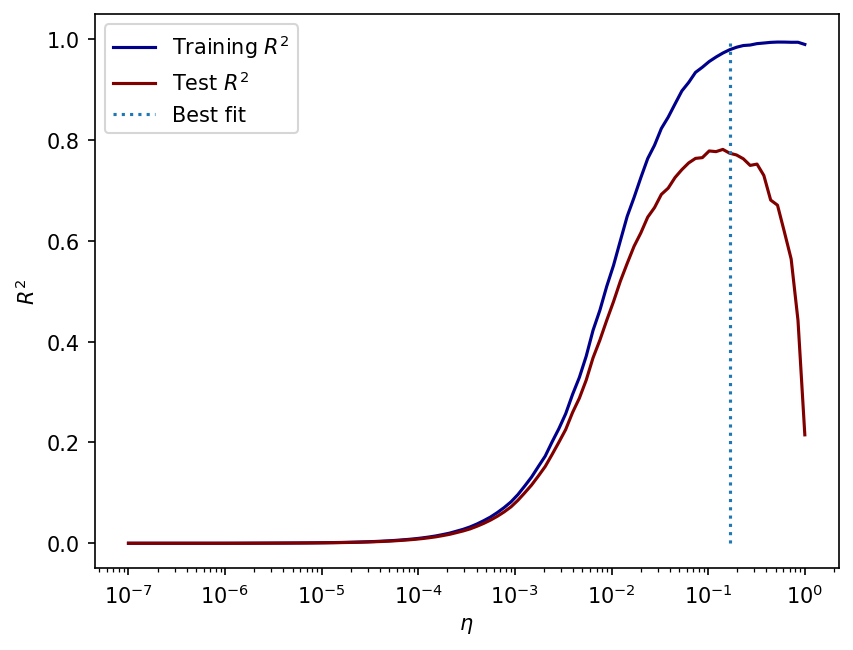

In [149]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(eta, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(eta, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(0.16984948183848828, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.set_xlabel('$\eta$')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [150]:
# Set array of eta values
reg_lambda = logspace(-7, 3, 200)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, lambda_value in enumerate(reg_lambda):
    # Set a new model
    xgbr = XGBRegressor(nthread = -1, 
                        colsample_bylevel = 0.27089875569868677,
                        colsample_bynode = 0.00023871262162442934,
                        colsample_bytree = 0.2521310852858073,
                        eta = 0.16984948183848828,
                        gamma = 4.936495008750438e-07, 
                        max_depth = 9, 
                        min_child_weight = 1.1130829945563475e-06, 
                        reg_alpha = 0.00027764020436691245, 
                        reg_lambda = lambda_value, 
                        subsample = 0.6725418424266979, 
                        tree_method = 'auto',
                        random_state = 10)
    
    # Train the model
    xgbr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = xgbr.predict(X_train.values)
    test_predictions = xgbr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

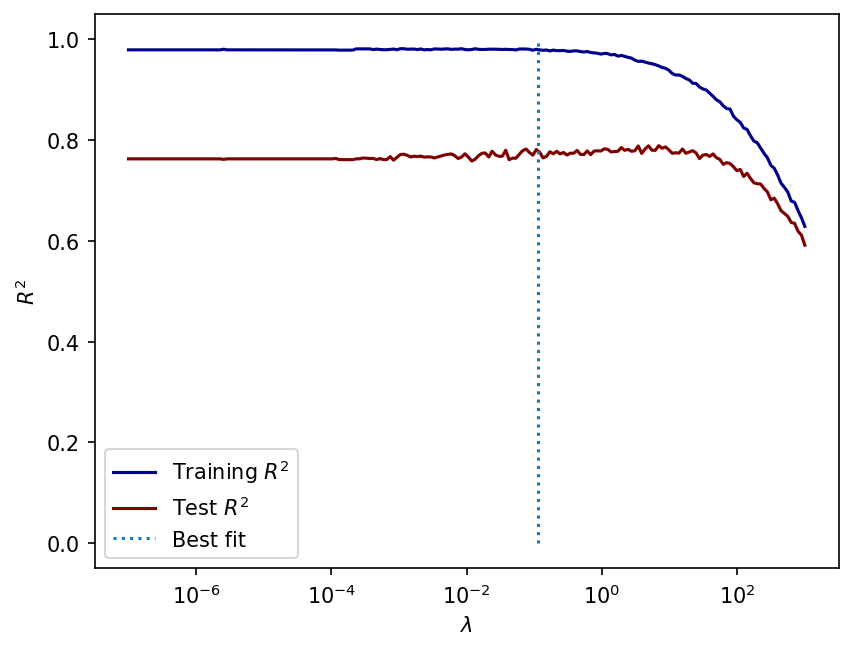

In [151]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(reg_lambda, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(reg_lambda, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(0.11543156340963502, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.set_xlabel('$\lambda$')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [152]:
# Set array of eta values
reg_alpha = logspace(-7, 3, 200)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, alpha_value in enumerate(reg_alpha):
    # Set a new model
    xgbr = XGBRegressor(nthread = -1, 
                        colsample_bylevel = 0.27089875569868677,
                        colsample_bynode = 0.00023871262162442934,
                        colsample_bytree = 0.2521310852858073,
                        eta = 0.16984948183848828,
                        gamma = 4.936495008750438e-07, 
                        max_depth = 9, 
                        min_child_weight = 1.1130829945563475e-06, 
                        reg_alpha = alpha_value, 
                        reg_lambda = 0.11543156340963502, 
                        subsample = 0.6725418424266979, 
                        tree_method = 'auto',
                        random_state = 10)
    
    # Train the model
    xgbr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = xgbr.predict(X_train.values)
    test_predictions = xgbr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

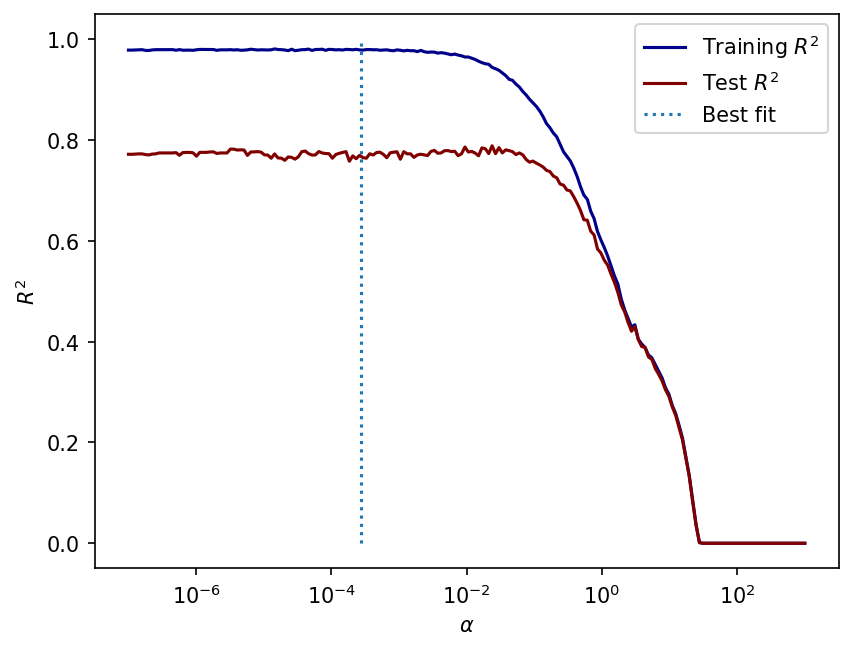

In [153]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(reg_alpha, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(reg_alpha, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(0.00027764020436691245, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

### KNN Regressor

In [154]:
# Packages
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from pandas import read_csv
from numpy import arange, int64
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [173]:
# Dataset
df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_1sigma_oversampled_98imp_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# KNN Regressor
"""knnr = KNeighborsRegressor(weights = 'distance',
                           n_neighbors = 194, 
                           leaf_size = 356,
                           algorithm = 'kd_tree')"""
knnr = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 6, 
                            p = 2, 
                            weights = 'distance')

In [174]:
# Train the model
knnr.fit(X_train.values, y_train.values)

KNeighborsRegressor(metric='manhattan', n_jobs=1, n_neighbors=6, p=1,
                    weights='distance')

In [175]:
# Predict
train_predictions = knnr.predict(X_train.values)
test_predictions = knnr.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 0.9999994936561425
R^2 over test data: 0.8950831044933107


In [129]:
# Set array of eta values
k = arange(1, 201, 1, dtype = int64)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, k_value in enumerate(k):
    # Set a new model
    knnr = KNeighborsRegressor(algorithm = 'auto', 
                               leaf_size = 30, 
                               metric = 'manhattan', 
                               metric_params = None, 
                               n_jobs = 1, 
                               n_neighbors = k_value, 
                               p = 2, 
                               weights = 'distance')
    
    # Train the model
    knnr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = knnr.predict(X_train.values)
    test_predictions = knnr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

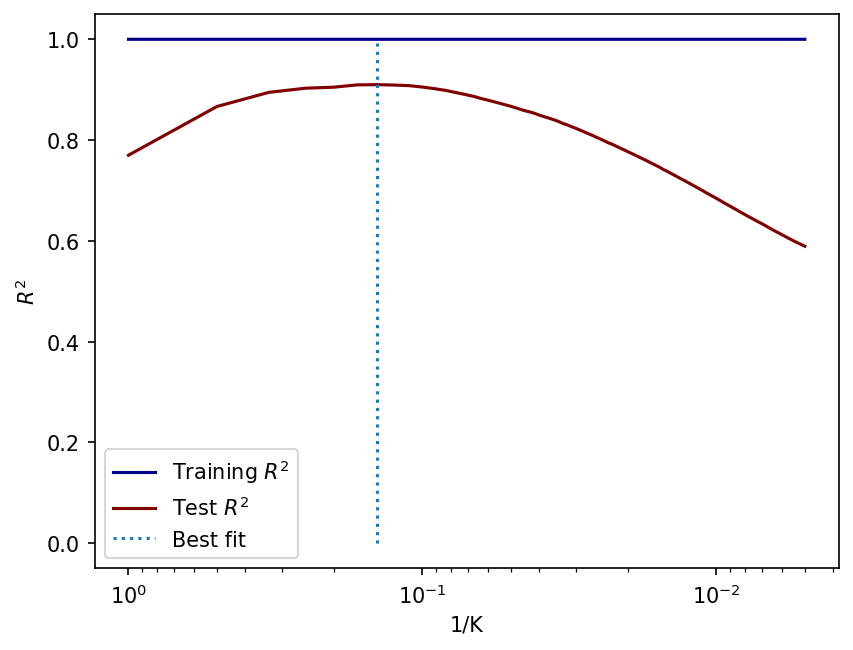

In [136]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(1/k, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(1/k, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(1/7, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel('1/K')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [137]:
# Set array of eta values
leaf_size = arange(1, 201, 1, dtype = int64)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, leaf_value in enumerate(leaf_size):
    # Set a new model
    knnr = KNeighborsRegressor(algorithm = 'auto', 
                               leaf_size = leaf_value, 
                               metric = 'manhattan', 
                               metric_params = None, 
                               n_jobs = 1, 
                               n_neighbors = 7, 
                               p = 2, 
                               weights = 'distance')
    
    # Train the model
    knnr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = knnr.predict(X_train.values)
    test_predictions = knnr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

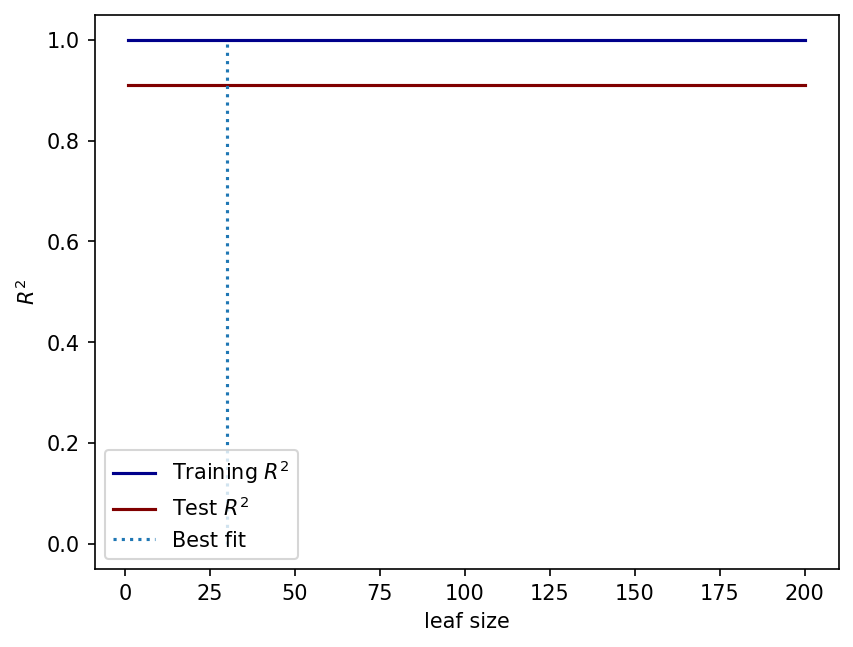

In [138]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(leaf_size, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(leaf_size, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(30, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
#ax.set_xscale('log')
ax.set_xlabel('leaf size')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()